# **Week 5  : Advanced Data Manipulation with Pandas**

# Project: Customer Sales Analysis

### Data loading and checking for missing values.

In [75]:
import pandas as pd

sales_df = pd.read_csv('sales_data.csv')
customer_df = pd.read_csv('customer_data.csv')

In [76]:
customer_df.head()

,CustomerID,CustomerName,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,CUST-001,Samantha Anderson,52,83.76,4393.99,One year,Mailed check,No,0,Yes
1,CUST-002,Patricia Jimenez,15,108.72,1638.54,Month-to-month,Electronic check,Yes,1,Yes
2,CUST-003,Emily Young,72,67.22,4639.94,One year,Electronic check,No,1,Yes
3,CUST-004,Mark Moore,61,31.96,1822.64,Month-to-month,Credit card,No,0,Yes
4,CUST-005,Jack Wilson,21,91.32,2039.60,Month-to-month,Credit card,Yes,0,No


In [77]:
sales_df.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2025-06-04,Streaming Stick,5,49.99,CUST-004,West,249.95
1,2025-10-10,Security Camera,2,129.99,CUST-019,Central,259.98
2,2025-09-12,Tech Support,1,29.99,CUST-070,East,29.99
3,2025-08-08,Security Camera,4,129.99,CUST-098,Central,519.96
4,2025-05-07,Router Pro,4,89.99,CUST-082,West,359.96


because I planned to merge the 2 datset on customer id i want them two column name same.

In [78]:
sales_df = sales_df.rename(columns={'Customer_ID': 'CustomerID'})

In [79]:
print("Cheecking for Null values")
print(f'Sales dataset: \n')
print(sales_df.isna().sum())
print(f'\nCustomer dataset:\n')
print(customer_df.isna().sum())

Cheecking for Null values
Sales dataset: 

Date           0
Product        0
Quantity       0
Price          0
CustomerID     0
Region         0
Total_Sales    0
dtype: int64

Customer dataset:

CustomerID          0
CustomerName        0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64


### Prepareing the data

I will merge this two dataset into using customer ID as common.

In [80]:
merged_df = sales_df.merge(customer_df,on='CustomerID')
merged_df.head()

,Date,Product,Quantity,Price,CustomerID,Region,Total_Sales,CustomerName,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,2025-06-04,Streaming Stick,5,49.99,CUST-004,West,249.95,Mark Moore,61,31.96,1822.64,Month-to-month,Credit card,No,0,Yes
1,2025-10-10,Security Camera,2,129.99,CUST-019,Central,259.98,Christopher Patel,22,44.93,910.84,Two year,Electronic check,Yes,0,No
2,2025-09-12,Tech Support,1,29.99,CUST-070,East,29.99,George Lewis,24,87.21,2239.10,Month-to-month,Bank transfer,Yes,0,Yes
3,2025-08-08,Security Camera,4,129.99,CUST-098,Central,519.96,Anna Smith,62,45.79,2874.54,One year,Credit card,Yes,0,No
4,2025-05-07,Router Pro,4,89.99,CUST-082,West,359.96,Patrick Anderson,63,24.08,1482.93,Month-to-month,Electronic check,Yes,1,Yes


In [81]:
merged_df.shape

(500, 16)

In [82]:
mdf = merged_df.copy(deep=True)

Adding a Month_name Column

In [83]:
mdf['Date'] = pd.to_datetime(mdf['Date'])
mdf.head(1)

,Date,Product,Quantity,Price,CustomerID,Region,Total_Sales,CustomerName,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,2025-06-04,Streaming Stick,5,49.99,CUST-004,West,249.95,Mark Moore,61,31.96,1822.64,Month-to-month,Credit card,No,0,Yes


In [84]:
mdf['monthname']= mdf['Date'].dt.month_name()
mdf.head(2)

,Date,Product,Quantity,Price,CustomerID,Region,Total_Sales,CustomerName,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn,monthname
0,2025-06-04,Streaming Stick,5,49.99,CUST-004,West,249.95,Mark Moore,61,31.96,1822.64,Month-to-month,Credit card,No,0,Yes,June
1,2025-10-10,Security Camera,2,129.99,CUST-019,Central,259.98,Christopher Patel,22,44.93,910.84,Two year,Electronic check,Yes,0,No,October


### Calculating Metrics:

In [85]:
monthly_performance = mdf.groupby('monthname')['Total_Sales'].sum().reset_index().sort_values(by='Total_Sales', ascending=False)

In [86]:
customer_totalsales = mdf.groupby('CustomerID')['Total_Sales'].sum().reset_index().sort_values(by='Total_Sales' , ascending=False)

In [87]:
reginal_sales = mdf.groupby('Region')['Total_Sales'].sum().reset_index()

In [88]:
#filter the '0' value churn customer and their total sales
stayed_customer = mdf[mdf['Churn']== 'No'].groupby('CustomerID')['Total_Sales'].sum().reset_index()
stayed_customer.sort_values(by='Total_Sales',ascending=False, inplace=True)

In [89]:
#to find best selling product monthly
prd_sales = mdf.groupby(['monthname', 'Product'])['Total_Sales'].sum().reset_index()
prd_sales.head(4)

,monthname,Product,Total_Sales
0,April,Fiber Optic Setup,1799.91
1,April,Router Pro,1349.85
2,April,Security Camera,4029.69
3,April,Streaming Stick,249.95


In [90]:
bestSellingPrdt_monthly = prd_sales.sort_values(by='Total_Sales', ascending=False).drop_duplicates('monthname')
bestSellingPrdt_monthly.head(4)

,monthname,Product,Total_Sales
20,January,Fiber Optic Setup,12199.39
40,May,Fiber Optic Setup,8399.58
15,February,Fiber Optic Setup,7799.61
5,August,Fiber Optic Setup,6199.69


## Data Visualzation

### Pivot Tables

In [91]:
print("pivot table to see Average Tenure and \nChurn count by Contract type\n")
pivot_analysis = customer_df.pivot_table(
    index='Contract', 
    columns='Churn', 
    values='CustomerID', 
    aggfunc='count'
)
print(pivot_analysis)

pivot table to see Average Tenure and 
Churn count by Contract type

Churn           No  Yes
Contract               
Month-to-month  30   21
One year        15   16
Two year        12    6


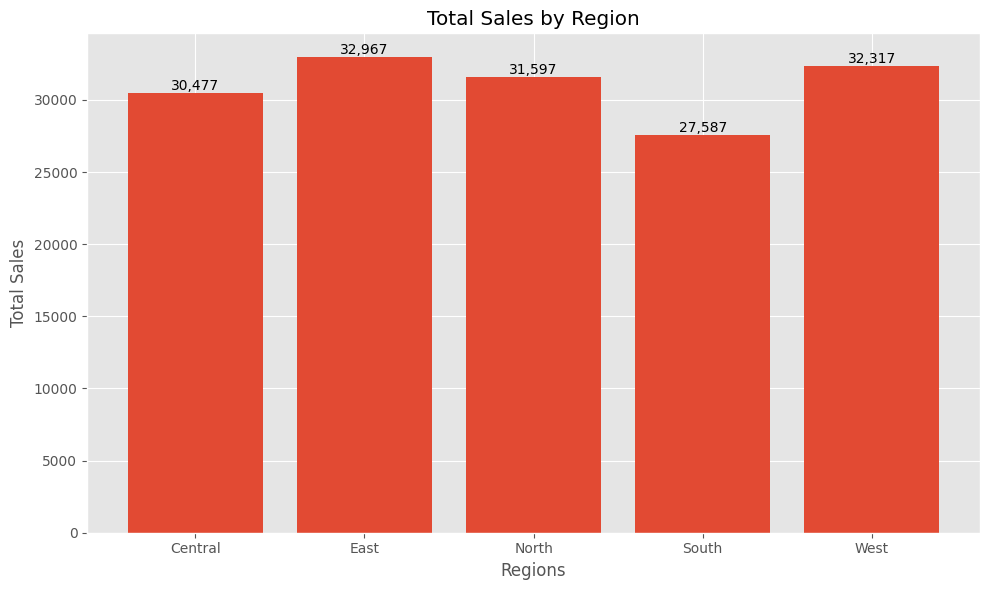

In [92]:
# Bar chart for regional sales
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(
    reginal_sales['Region'],
    reginal_sales['Total_Sales']
)
plt.xlabel('Regions')
plt.ylabel('Total Sales')
plt.title('Total Sales by Region')
for i, value in enumerate(reginal_sales['Total_Sales']):
    plt.text(i, value, f'{value:,.0f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

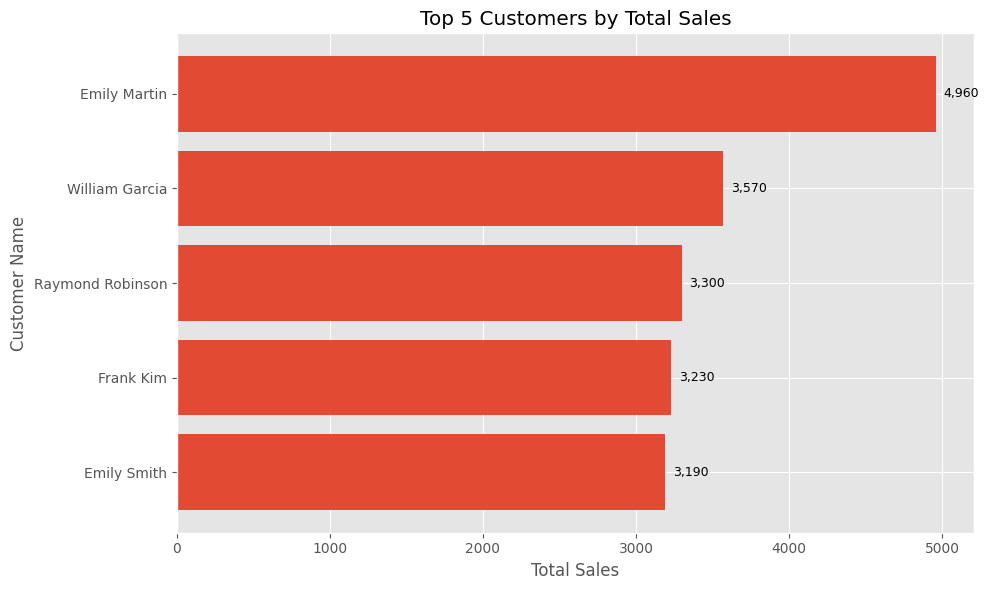

In [93]:
# Top 5 customers by total sales — horizontal bar chart
top5_customers = customer_totalsales.head(5).copy()
top5_customers = top5_customers.merge(
    mdf[['CustomerID', 'CustomerName']].drop_duplicates('CustomerID'),
    on='CustomerID',
    how='left'
)

plt.figure(figsize=(10, 6))
bars = plt.barh(
    top5_customers['CustomerName'],
    top5_customers['Total_Sales']
)
plt.xlabel('Total Sales')
plt.ylabel('Customer Name')
plt.title('Top 5 Customers by Total Sales')
plt.gca().invert_yaxis()
for bar, value in zip(bars, top5_customers['Total_Sales']):
    plt.text(
        bar.get_width() + max(top5_customers['Total_Sales']) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{value:,.0f}',
        va='center',
        ha='left',
        fontsize=9
    )
plt.tight_layout()
plt.show()

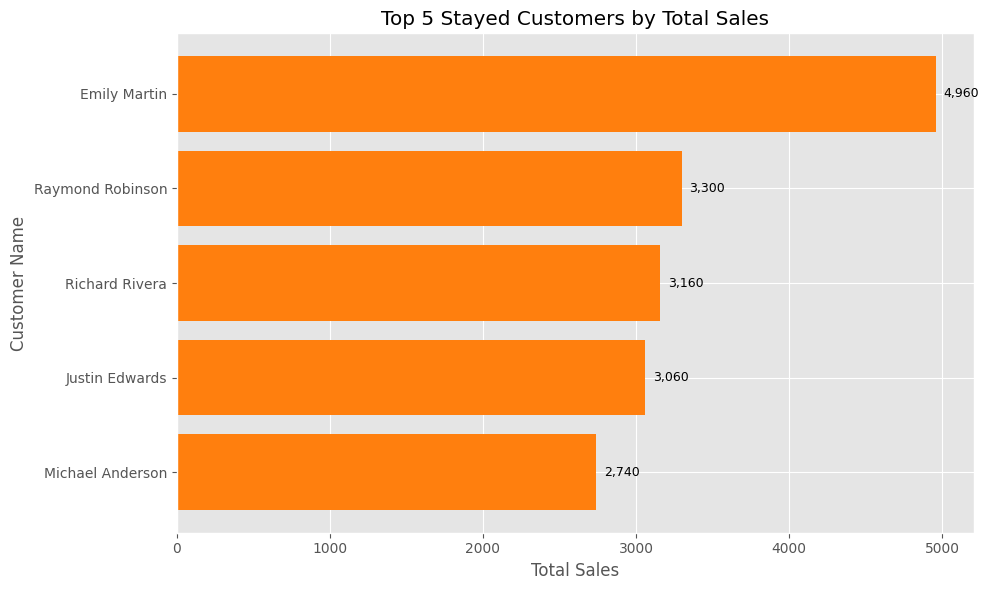

In [94]:
# Top 5 stayed customers by total sales — horizontal bar chart
top5_stayed_customers = stayed_customer.sort_values(by='Total_Sales', ascending=False).head(5).copy()
top5_stayed_customers = top5_stayed_customers.merge(
    mdf[['CustomerID', 'CustomerName']].drop_duplicates('CustomerID'),
    on='CustomerID',
    how='left'
)

plt.figure(figsize=(10, 6))
bars = plt.barh(
    top5_stayed_customers['CustomerName'],
    top5_stayed_customers['Total_Sales'],
    color='tab:orange'
)
plt.xlabel('Total Sales')
plt.ylabel('Customer Name')
plt.title('Top 5 Stayed Customers by Total Sales')
plt.gca().invert_yaxis()
for bar, value in zip(bars, top5_stayed_customers['Total_Sales']):
    plt.text(
        bar.get_width() + max(top5_stayed_customers['Total_Sales']) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{value:,.0f}',
        va='center',
        ha='left',
        fontsize=9
    )
plt.tight_layout()
plt.show()

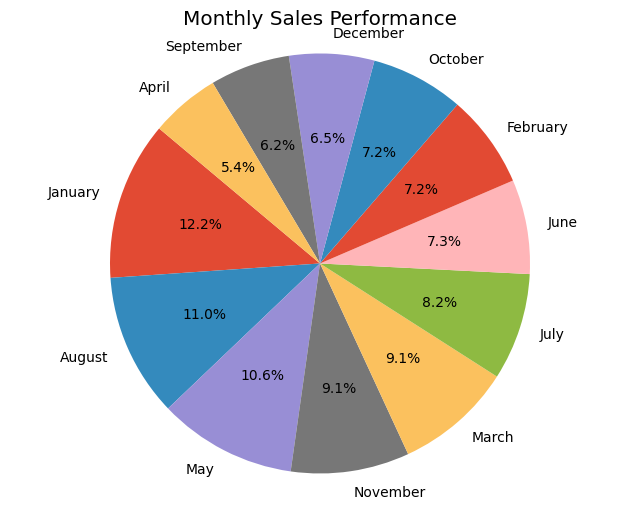

In [95]:
# Pie chart to show monthly performance
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.pie(
    monthly_performance['Total_Sales'],
    labels=monthly_performance['monthname'],
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 10}
)
plt.title('Monthly Sales Performance')
plt.axis('equal')
plt.show()

In [96]:
print("Display the best selling product Every Month")
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]
bestSellingPrdt_monthly['monthname'] = pd.Categorical(
    bestSellingPrdt_monthly['monthname'],
    categories=month_order,
    ordered=True
)
bestSellingPrdt_monthly.sort_values('monthname')[['monthname', 'Product', 'Total_Sales']]

Display the best selling product Every Month


,monthname,Product,Total_Sales
20,January,Fiber Optic Setup,12199.39
15,February,Fiber Optic Setup,7799.61
35,March,Fiber Optic Setup,5199.74
2,April,Security Camera,4029.69
40,May,Fiber Optic Setup,8399.58
30,June,Fiber Optic Setup,3799.81
25,July,Fiber Optic Setup,6199.69
5,August,Fiber Optic Setup,6199.69
55,September,Fiber Optic Setup,3799.81
50,October,Fiber Optic Setup,3999.80


In [97]:
print("Pivot Table to see the Total Charges\ngrouped by the Contract type:\n")

contract_value_pivot = customer_df.pivot_table(
    index='Contract', 
    values='TotalCharges', 
    aggfunc=['sum']
)

print(contract_value_pivot)

Pivot Table to see the Total Charges
grouped by the Contract type:

                        sum
               TotalCharges
Contract                   
Month-to-month    102415.59
One year           89257.09
Two year           42889.64


In [98]:
print("Pivot to see number of unique products per contract type")
cross_sell_pivot = mdf.pivot_table(
    index='Contract', 
    values='Product', 
    aggfunc='nunique'
)
print(cross_sell_pivot)

Pivot to see number of unique products per contract type
                Product
Contract               
Month-to-month        5
One year              5
Two year              5


**Retention Analysis** is the process of measuring how many customers "stick around" over a period of time.

In [100]:
print("Checking How much money is lost vs. kept?\n")
leakage = mdf.groupby('Churn')['Total_Sales'].sum()
retention_rate = (leakage['No'] / leakage.sum()) * 100
print(f"Total Revenue Retention Rate: {retention_rate:.2f}%")

Checking How much money is lost vs. kept?

Total Revenue Retention Rate: 59.34%
